# XGBClassifier
> Based on our initial Notebook, the best performing model was the XGBClassifier
> Accordingly, we here aim to maximize the results of this classifier

In [318]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, LearningCurveDisplay
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV

In [319]:
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Molecules_Toxicity_Classification.xlsx")
data.drop("Unnamed: 0", inplace=True, axis=1)
encoder = LabelEncoder()
data["Class"] = encoder.fit_transform(data["Class"])

In [320]:
X = data.drop("Class", axis=1)
y = data["Class"]

In [321]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.09, shuffle=True, random_state=0)

## Data Scaling

In [322]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

## Random oversampling
> Because we saw that SMOTE will likely not perform well, we go with Random Oversampling
> We realize that this might cause some overfitting, and we hope to counter this with L1 and L2 regularization

In [324]:
xgb_classifier = xgb.XGBClassifier(random_state=42)

In [325]:
from imblearn.pipeline import Pipeline # Import ImbPipeline

pipeline = Pipeline([ # Use ImbPipeline
    ("scaler", StandardScaler()),
    ("ros", RandomOverSampler(random_state=42)),
    ("classifier", xgb_classifier)
])

## Randomized Search
> We perform randomized search on a multitude of hyperparameters to find the best ones. Note that the L1 and L2 parameters are intentionally set to be relatively high

In [326]:
params = {"classifier__learning_rate":[0.01, 0.1, 0.8, 1], "classifier__n_estimators":[50, 100, 200, 300], "classifier__gamma":[0, 0.1, 1, 5, 10], "classifier__max_depth":[2, 4, 6, 8], "classifier__max_delta_step":[0, 1, 5, 10], "classifier__lambda":[0.5, 1, 2, 5, 10], "classifier__alpha":[0, 0.1, 0.5, 1, 5]}

In [327]:
# params = {"classifier__learning_rate":[0.01, 0.1, 0.3, 0.4, 0.5, 0.8, 1], "classifier__n_estimators":[50, 100, 200, 300], "classifier__gamma":[0, 0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], "classifier__max_depth":[2, 4, 6, 8, 10, 12, 14, 15], "classifier__max_delta_step":[0, 1, 2, 4, 5, 8, 10], "classifier__lambda":[0.5, 1, 1.5, 2, 3, 4, 5, 10], "classifier__alpha":[0, 0.1, 0.5, 1, 2, 3, 4, 5], "classifier__subsample":[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]}

In [328]:
clf = RandomizedSearchCV(pipeline, params, n_iter=150, cv=8, random_state=0, n_jobs=-1)

In [ ]:
clf.fit(X_train, y_train)

RandomizedSearchCV(cv=8,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('ros',
                                              RandomOverSampler(random_state=42)),
                                             ('classifier',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric=None,
                                                            feature_t...
                                                            random_state=42, ...))]),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'classifier__alpha': [0, 0.1, 0.5, 1,
                                                              5],
                                        'classifier__gamma': [0, 0.1, 1, 5, 10],
                                        'classifier__lambda': [0.5, 1, 2, 5,
                                                               10],
                                        'classifier__learning_rate': [0.01, 0.1,
                                                                      0.8, 1],
                                        'classifier__max_delta_step': [0, 1, 5,
                                                                       10],
                                        'classifier__max_depth': [2, 4, 6, 8],
                                        'classifier__n_estimators': [50, 100,
                                                                     200,
                                                                     300]},
                   random_state=0)

## Unexpected Results
> We see that CV accuracy is quite low. We later realized that this was due to us using randomized search incorrectly. The search space is extremely large and our 150 iterations dont cover 1% of it, meaning that the probability of finding the optimal parameters is less than 1%

In [ ]:
cv_results = pd.DataFrame(clf.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__max_delta_step,param_classifier__learning_rate,param_classifier__lambda,param_classifier__gamma,...,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
0,0.826489,0.206077,0.027038,0.010568,50,8,5,0.80,0.5,1.0,...,0.500000,0.722222,0.555556,0.666667,0.444444,0.611111,0.555556,0.569444,0.086736,50
1,8.759295,2.164486,0.028764,0.016067,300,8,5,0.01,2.0,5.0,...,0.555556,0.722222,0.555556,0.500000,0.500000,0.500000,0.500000,0.541667,0.072169,97
2,3.927698,1.162534,0.029974,0.014083,100,4,10,0.10,5.0,1.0,...,0.555556,0.611111,0.611111,0.611111,0.555556,0.444444,0.555556,0.562500,0.051501,59
3,1.487838,0.377107,0.049904,0.027730,50,2,0,1.00,1.0,0.0,...,0.555556,0.500000,0.555556,0.666667,0.555556,0.611111,0.555556,0.562500,0.051501,59
4,6.971994,1.042040,0.047144,0.032835,300,2,0,0.10,1.0,0.0,...,0.555556,0.611111,0.500000,0.611111,0.500000,0.555556,0.666667,0.576389,0.055120,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.792230,0.020895,0.016987,0.001203,100,4,1,0.80,5.0,5.0,...,0.555556,0.666667,0.555556,0.555556,0.500000,0.555556,0.666667,0.569444,0.060540,50
146,0.814895,0.022718,0.017293,0.001342,100,6,0,1.00,1.0,10.0,...,0.555556,0.722222,0.555556,0.500000,0.444444,0.444444,0.611111,0.541667,0.086736,97
147,3.779048,0.478594,0.020912,0.007127,300,8,10,0.10,0.5,0.1,...,0.666667,0.666667,0.666667,0.555556,0.611111,0.500000,0.611111,0.618056,0.058515,4
148,1.297359,0.288477,0.029859,0.008559,50,2,0,0.01,10.0,0.0,...,0.555556,0.555556,0.555556,0.500000,0.444444,0.388889,0.444444,0.493056,0.058515,143


In [ ]:
clf.best_params_

{'classifier__n_estimators': 200,
 'classifier__max_depth': 6,
 'classifier__max_delta_step': 10,
 'classifier__learning_rate': 0.8,
 'classifier__lambda': 5,
 'classifier__gamma': 0,
 'classifier__alpha': 0.5}

In [ ]:
best_clf = clf.best_estimator_

In [ ]:
y_pred = best_clf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.00      0.00      0.00         5

    accuracy                           0.47        15
   macro avg       0.29      0.35      0.32        15
weighted avg       0.39      0.47      0.42        15



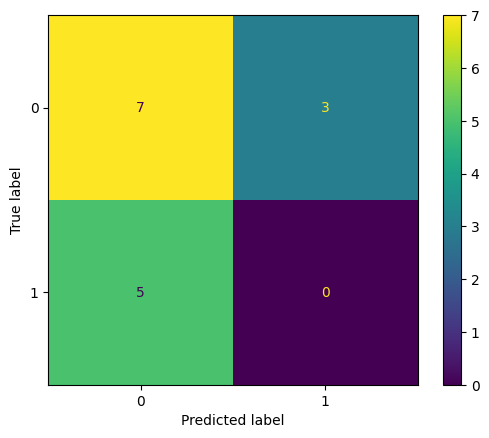

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

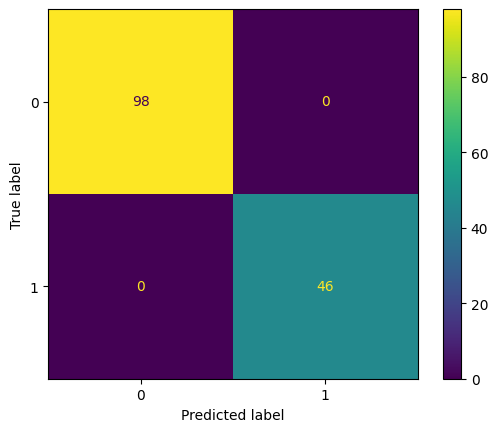

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_train, best_clf.predict(X_train))).plot()

## Retrain on whole training set


In [ ]:
# final = xgb.XGBClassifier(**clf.best_params_)

In [ ]:
# ros = RandomOverSampler(random_state=42)
# X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ros', RandomOverSampler(random_state=42)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [ ]:
y_final_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test, y_final_pred))

              precision    recall  f1-score   support

           0       0.55      0.60      0.57        10
           1       0.00      0.00      0.00         5

    accuracy                           0.40        15
   macro avg       0.27      0.30      0.29        15
weighted avg       0.36      0.40      0.38        15



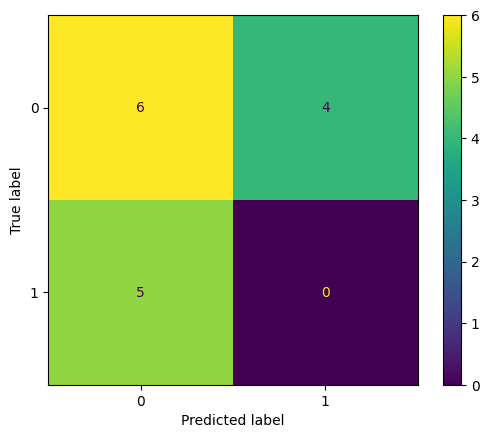

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_final_pred)).plot()